<a href="https://colab.research.google.com/github/riack16/Proyecto-rendimiento-acad-mico/blob/main/S100_Equipo4_ParteI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (4, 2), "figure.dpi": 80,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 9})

df = pd.read_csv("https://raw.githubusercontent.com/riack16/Proyecto-rendimiento-acad-mico/main/StudentPerformanceFactors.csv")


print("Filas y columnas:", df.shape)

Filas y columnas: (6607, 20)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6605 non-null   float64
 1   Attendance                  6605 non-null   float64
 2   Parental_Involvement        6606 non-null   object 
 3   Access_to_Resources         6605 non-null   object 
 4   Extracurricular_Activities  6605 non-null   object 
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6606 non-null   object 
 8   Internet_Access             6606 non-null   object 
 9   Tutoring_Sessions           6606 non-null   float64
 10  Family_Income               6606 non-null   object 
 11  Teacher_Quality             6528 non-null   object 
 12  School_Type                 6605 non-null   object 
 13  Peer_Influence              6606 

In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6605.000000,6605.000000,6607.00000,6607.000000,6606.000000,6604.000000,6605.000000
mean,19.973808,79.948978,7.02906,75.070531,1.493642,2.967293,67.215291
std,5.995209,11.736506,1.46812,14.399784,1.230648,1.031015,4.217186
min,0.000000,-91.000000,4.00000,50.000000,0.000000,0.000000,-65.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [ ]:
fuera_rango = df[ (df['Exam_Score'] < 0) | (df['Exam_Score'] > 100) | (df['Attendance'] < 0) ]

resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Filas_Totales': len(df),
    'Nulos': df.isnull().sum(),
}
)
resumen['Media'] =  round( df.select_dtypes(include='number').mean() , 1)
resumen['Mediana']= round( df.select_dtypes(include='number').median() , 1)
resumen['Minimo'] = round( df.select_dtypes(include='number').min(), 1)
resumen['Maximo'] = round( df.select_dtypes(include='number').max(),1)
resumen ['%_Falta'] = round( resumen ['Nulos'] / resumen['Filas_Totales'] * 100, 2)
Resumenf = resumen.drop(columns=['Filas_Totales','Nulos'])
pd.set_option('display.expand_frame_repr', False)
print(Resumenf)

print('╔══════════════════════════════════════════════════════╗')
print('║           RESUMEN DE DE DATOS                        ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Total de filas originales            : {len(df):>6}       ║')
print(f'║  Total de Columnas originales         : {len(df.columns):>6}       ║')
print(f'║  Valores nulos                        : {df.isnull().sum().sum():>6}       ║')
print(f'║  Valores inconsistentes               : {len(fuera_rango):>6}       ║')
print(f'║  Valores duplicados                   : {len(df[df.duplicated()]):>6}       ║')

print('╚══════════════════════════════════════════════════════╝')

                               Tipo  Media  Mediana  Minimo  Maximo  %_Falta
Hours_Studied               float64   20.0     20.0     0.0    44.0     0.03
Attendance                  float64   79.9     80.0   -91.0   100.0     0.03
Parental_Involvement         object    NaN      NaN     NaN     NaN     0.02
Access_to_Resources          object    NaN      NaN     NaN     NaN     0.03
Extracurricular_Activities   object    NaN      NaN     NaN     NaN     0.03
Sleep_Hours                   int64    7.0      7.0     4.0    10.0     0.00
Previous_Scores               int64   75.1     75.0    50.0   100.0     0.00
Motivation_Level             object    NaN      NaN     NaN     NaN     0.02
Internet_Access              object    NaN      NaN     NaN     NaN     0.02
Tutoring_Sessions           float64    1.5      1.0     0.0     8.0     0.02
Family_Income                object    NaN      NaN     NaN     NaN     0.02
Teacher_Quality              object    NaN      NaN     NaN     NaN     1.20

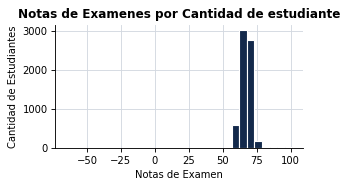

In [ ]:
plt.hist(df["Exam_Score"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Notas de Examen")
plt.ylabel("Cantidad de Estudiantes")
plt.title("Notas de Examenes por Cantidad de estudiante")
plt.show()

Limpieza

In [ ]:
# Paso 1: quitar las 3 filas con valores imposibles
df_limpio = df[(df["Attendance"] >= 0) & (df["Attendance"] <= 100) &
               (df["Exam_Score"] >= 0) & (df["Exam_Score"] <= 100)].copy()

# Paso 2: quitar las filas que tengan algún dato faltante
df_limpio = df_limpio.dropna()

print("Filas originales:", df.shape[0])
print("Filas después de limpiar:", df_limpio.shape[0])

Filas originales: 6607
Filas después de limpiar: 6353


In [ ]:
# Paso 3: convertir las columnas de texto a columnas numéricas (0 y 1)
df_codificado = pd.get_dummies(df_limpio, drop_first=True)

print("Columnas antes:", df_limpio.shape[1])
print("Columnas después:", df_codificado.shape[1])
df_codificado.head()

Columnas antes: 20
Columnas después: 28


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23.0,84.0,7,73,0.0,3.0,67.0,True,False,False,...,True,True,False,True,False,True,False,False,True,True
2,24.0,98.0,7,91,2.0,4.0,74.0,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29.0,89.0,8,98,1.0,4.0,71.0,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19.0,92.0,6,65,3.0,4.0,70.0,False,True,False,...,False,True,True,False,False,False,False,False,True,False
5,19.0,88.0,8,89,3.0,3.0,71.0,False,True,False,...,True,True,False,True,False,False,True,False,True,True


Paso 4: Separacion que se va a predecir

In [ ]:


#Paso 4: Separar variable objetivo (y) del resto (x), y partir en entrenamiento/prueba

X = df_codificado.drop(columns=["Exam_Score"])
y = df_codificado["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Filas para entrenar:", X_train.shape[0])
print("Filas para probar:", X_test.shape[0])

Filas para entrenar: 5082
Filas para probar: 1271


In [ ]:
# Paso 5: baseline - predecir siempre el promedio
promedio_train = y_train.mean()
pred_baseline_test = np.full(shape = y_test.shape, fill_value = promedio_train)

In [ ]:
#Paso 6: Regresion Lineal
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr_train = model_lr.predict(X_train)
pred_lr_test = model_lr.predict(X_test)

In [ ]:
#Paso 7: Comparar baseline vs Regresion Lineal
resultados = pd.DataFrame({
    "Modelo": ["Baseline (promedio)", "Regresion Lineal"],
    "RMSE_test":[
        np.sqrt(mean_squared_error(y_test, pred_baseline_test)),
        np.sqrt(mean_squared_error(y_test, pred_lr_test)),
    ],
    "MAE_test":[
        mean_absolute_error(y_test, pred_baseline_test),
        mean_absolute_error(y_test, pred_lr_test),
    ],
    "R2_test":[
        r2_score(y_test, pred_baseline_test),
        r2_score(y_test, pred_lr_test),
    ],
})
resultados

,Modelo,RMSE_test,MAE_test,R2_test
0,Baseline (promedio),3.977706,2.897528,-0.000109
1,Regresion Lineal,1.972774,0.453920,0.753999
